In [ ]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
RESULTS_DIR = Path("../pp_results")

In [2]:
def discover_runs(results_dir: Path) -> dict[str, Path]:
    """Find every model_federated_avail_{regime}_q{q}/ folder."""
    runs = {}
    for p in sorted(results_dir.glob("model_federated_avail_*")):
        if p.is_dir():
            tag = p.name.replace("model_federated_avail_", "")
            runs[tag] = p
    return runs


def load_global_loss(run_dir: Path) -> pd.DataFrame | None:
    npy_path = run_dir / "global_loss.npy"
    if not npy_path.exists():
        return None
    arr = np.load(npy_path)  # shape (3, num_rounds): [rounds, train, valid]
    return pd.DataFrame({"round": arr[0], "train_loss": arr[1], "valid_loss": arr[2]})


def load_fairness_metrics(run_dir: Path) -> pd.DataFrame | None:
    path = run_dir / "fairness_metrics.jsonl"
    if not path.exists():
        return None
    rows = [json.loads(line) for line in path.open() if line.strip()]
    return pd.DataFrame(rows) if rows else None


def load_participation(run_dir: Path) -> pd.DataFrame | None:
    path = run_dir / "participation_log.csv"
    if not path.exists():
        return None
    return pd.read_csv(path)


def parse_tag(tag: str) -> tuple[str, str]:
    """'random_q0p0' -> ('random', 'q=0.0')."""
    regime, q_part = tag.rsplit("_q", 1)
    q = q_part.replace("p", ".")
    return regime, f"q={q}"


def load_fairness_log(run_dir: Path) -> pd.DataFrame | None:
    """Per-round, per-client valid loss (fairness_log.csv) -- richer than the
    single final-round snapshot in fairness_metrics.jsonl."""
    path = run_dir / "fairness_log.csv"
    if not path.exists():
        return None
    return pd.read_csv(path)

In [3]:
runs = discover_runs(RESULTS_DIR)
if not runs:
    print(f"No runs found under {RESULTS_DIR}/model_federated_avail_*. "
          f"Run run_availability_experiments.py (or the manual pyproject.toml + flwr run loop) first.")
else:
    print(f"Found {len(runs)} runs:")
    for tag in runs:
        regime, q_label = parse_tag(tag)
        print(f"  {tag:<25} -> regime={regime:<16} strategy={q_label}")

Found 9 runs:
  full_q0p0                 -> regime=full             strategy=q=0.0
  full_q2p0                 -> regime=full             strategy=q=2.0
  full_q5p0                 -> regime=full             strategy=q=5.0
  random_q0p0               -> regime=random           strategy=q=0.0
  random_q2p0               -> regime=random           strategy=q=2.0
  random_q5p0               -> regime=random           strategy=q=5.0
  size_correlated_q0p0      -> regime=size_correlated  strategy=q=0.0
  size_correlated_q2p0      -> regime=size_correlated  strategy=q=2.0
  size_correlated_q5p0      -> regime=size_correlated  strategy=q=5.0


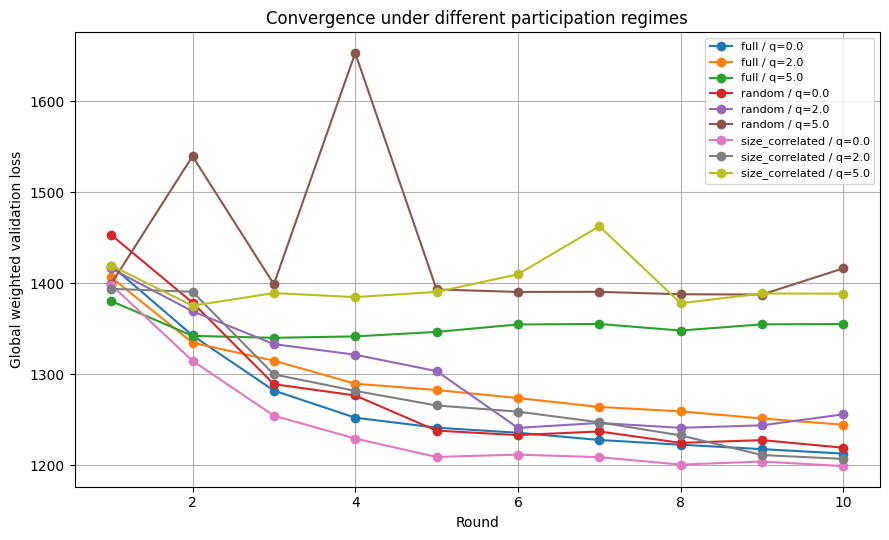

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for tag, run_dir in runs.items():
    df = load_global_loss(run_dir)
    if df is None:
        print(f"  [WARN] no global_loss.npy for {tag}")
        continue
    regime, q_label = parse_tag(tag)
    ax.plot(df["round"], df["valid_loss"], marker="o", label=f"{regime} / {q_label}")

ax.set_xlabel("Round")
ax.set_ylabel("Global weighted validation loss")
ax.set_title("Convergence under different participation regimes")
ax.legend(fontsize=8)
ax.grid(True)
fig.tight_layout()
plt.show()

In [5]:
summary_rows = []
for tag, run_dir in runs.items():
    regime, q_label = parse_tag(tag)
    fdf = load_fairness_metrics(run_dir)
    gdf = load_global_loss(run_dir)
    row = {"tag": tag, "regime": regime, "strategy": q_label}
    if gdf is not None and len(gdf):
        row["final_train_loss"] = gdf["train_loss"].iloc[-1]
        row["final_valid_loss"] = gdf["valid_loss"].iloc[-1]
    if fdf is not None and len(fdf):
        last = fdf.iloc[-1]
        row["final_jain_index"] = last.get("jain_index")
        row["final_variance"] = last.get("variance")
        row["final_worst_client_loss"] = last.get("worst_client_loss")
        row["final_best_client_loss"] = last.get("best_client_loss")
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values(["regime", "strategy"]).reset_index(drop=True)
summary_df

,tag,regime,strategy,final_train_loss,final_valid_loss,final_jain_index,final_variance,final_worst_client_loss,final_best_client_loss
0,full_q0p0,full,q=0.0,1200.455712,1212.883066,0.498584,2.953393e+06,5378.495117,537.484436
1,full_q2p0,full,q=2.0,1232.412235,1244.576484,0.589664,1.881921e+06,4552.699707,673.220581
2,full_q5p0,full,q=5.0,1339.842983,1355.272684,0.643190,1.649645e+06,4352.363770,784.502380
3,random_q0p0,random,q=0.0,1207.642574,1219.324334,0.504448,2.906879e+06,5351.865723,538.476196
4,random_q2p0,random,q=2.0,1242.669385,1256.035478,0.584772,1.964724e+06,4640.126465,673.032715
5,random_q5p0,random,q=5.0,1402.929399,1416.466371,0.656395,1.665547e+06,4360.505859,813.545288
6,size_correlated_q0p0,size_correlated,q=0.0,1185.223755,1199.163450,0.507245,2.768923e+06,5223.832031,533.282104
7,size_correlated_q2p0,size_correlated,q=2.0,1196.033699,1207.036432,0.504818,2.806576e+06,5255.063477,543.987610
8,size_correlated_q5p0,size_correlated,q=5.0,1375.945363,1388.646078,0.656472,1.612080e+06,4395.279297,821.340393


In [6]:
client_loss_rows = []
for tag, run_dir in runs.items():
    regime, q_label = parse_tag(tag)
    ldf = load_fairness_log(run_dir)
    if ldf is None or ldf.empty:
        continue
    last_round = ldf["round"].max()
    final = ldf[ldf["round"] == last_round]
    for _, r in final.iterrows():
        client_loss_rows.append({
            "regime": regime,
            "strategy": q_label,
            "client_id": r["client_id"],
            "valid_loss": r["valid_loss"],
        })

client_loss_df = pd.DataFrame(client_loss_rows)
pivot = client_loss_df.pivot_table(index="client_id", columns=["regime", "strategy"], values="valid_loss")
pivot = pivot.sort_index()
pivot

regime            full                                 random               \
strategy         q=0.0        q=2.0        q=5.0        q=0.0        q=2.0   
client_id                                                                    
0.0        1181.104736  1220.824707  1332.479126  1238.766357  1209.639282   
1.0        5378.495117  4552.699707  4352.363770  5351.865723  4640.126465   
2.0         583.963440   725.795837   825.472046   596.499084   725.570435   
3.0         537.484436   673.220581   784.502380   538.476196   673.032715   
4.0         569.115051   733.365540   874.232239   572.908020   737.408630   
5.0         660.606079   836.182678   958.320740   665.968262   850.917053   
6.0        3085.012451  2769.388916  2943.652100  3076.857666  2807.222656   

regime                 size_correlated                            
strategy         q=5.0           q=0.0        q=2.0        q=5.0  
client_id                                                         
0.0        1396.902710     1223.863281  1136.590332  1395.791382  
1.0        4360.505859     5223.832031  5255.063477  4395.279297  
2.0         875.487305      582.926758   602.152283   856.042175  
3.0         813.545288      533.282104   543.987610   821.340393  
4.0         928.465149      566.628052   582.300476   932.649170  
5.0        1001.140198      659.632263   666.828247  1005.011963  
6.0        3110.127197     3027.908691  3053.624268  2880.106445

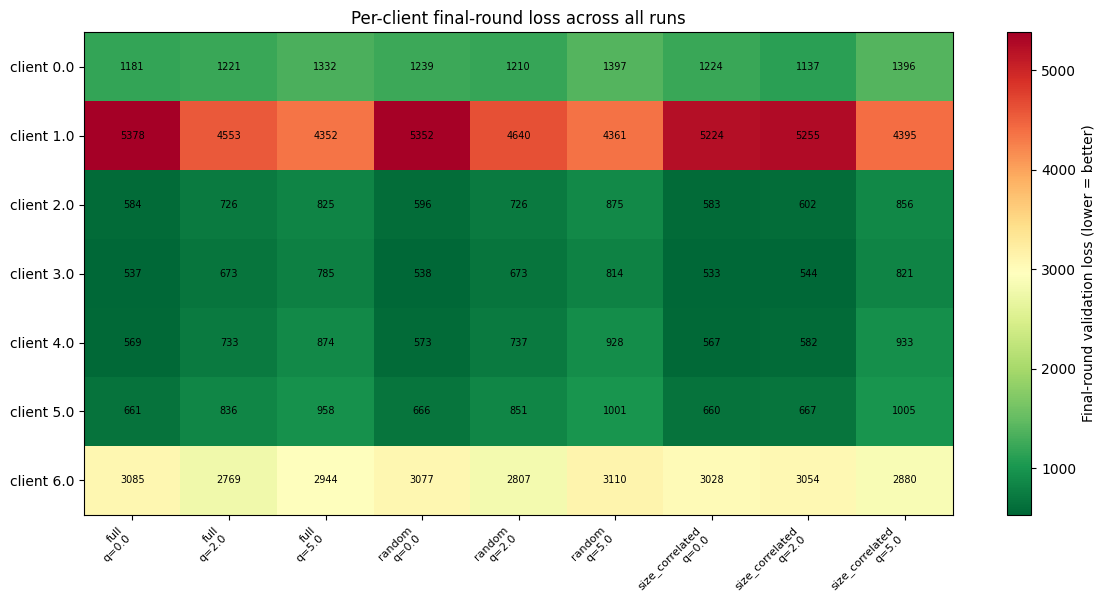

In [7]:
fig, ax = plt.subplots(figsize=(1.1 * len(pivot.columns) + 2, 0.6 * len(pivot) + 2))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn_r")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{r}\n{s}" for r, s in pivot.columns], fontsize=8, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"client {c}" for c in pivot.index])

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Final-round validation loss (lower = better)")
ax.set_title("Per-client final-round loss across all runs")
fig.tight_layout()
plt.show()

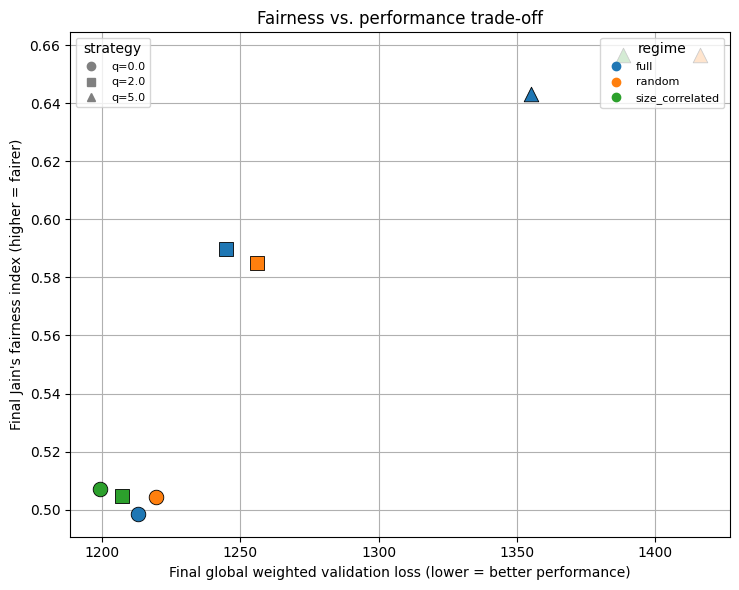

In [8]:
from matplotlib.lines import Line2D

marker_by_strategy = {"q=0.0": "o", "q=2.0": "s", "q=5.0": "^"}
color_by_regime = {"full": "tab:blue", "random": "tab:orange", "size_correlated": "tab:green"}

fig, ax = plt.subplots(figsize=(7.5, 6))
for _, row in summary_df.dropna(subset=["final_jain_index", "final_valid_loss"]).iterrows():
    marker = marker_by_strategy.get(row["strategy"], "x")
    color = color_by_regime.get(row["regime"], "gray")
    ax.scatter(
        row["final_valid_loss"], row["final_jain_index"],
        marker=marker, color=color, s=110, edgecolor="black", linewidth=0.6, zorder=3,
    )

ax.set_xlabel("Final global weighted validation loss (lower = better performance)")
ax.set_ylabel("Final Jain's fairness index (higher = fairer)")
ax.set_title("Fairness vs. performance trade-off")
ax.grid(True, zorder=0)

strategy_handles = [Line2D([0], [0], marker=m, color="gray", linestyle="", label=s)
                     for s, m in marker_by_strategy.items() if s in summary_df["strategy"].unique()]
regime_handles = [Line2D([0], [0], marker="o", color=c, linestyle="", label=r)
                   for r, c in color_by_regime.items() if r in summary_df["regime"].unique()]
leg1 = ax.legend(handles=strategy_handles, title="strategy", loc="upper left", fontsize=8)
ax.add_artist(leg1)
ax.legend(handles=regime_handles, title="regime", loc="upper right", fontsize=8)

fig.tight_layout()
plt.show()

In [9]:
part_rows = []
for tag, run_dir in runs.items():
    regime, q_label = parse_tag(tag)
    pdf = load_participation(run_dir)
    if pdf is None or pdf.empty:
        continue
    pdf = pdf.dropna(subset=["client_id"])
    grp = pdf.groupby("client_id").agg(
        mean_size=("client_size", "mean"),
        participation_rate=("available", "mean"),
        n_rounds=("round", "count"),
    ).reset_index()
    grp["regime"] = regime
    grp["strategy"] = q_label
    part_rows.append(grp)

if part_rows:
    part_df = pd.concat(part_rows, ignore_index=True)
else:
    part_df = pd.DataFrame()
    print("[WARN] no participation_log.csv found in any run")

part_df

,client_id,mean_size,participation_rate,n_rounds,regime,strategy
0,0.0,803.0,1.000000,9,full,q=0.0
1,1.0,510.0,1.000000,9,full,q=0.0
2,2.0,1550.0,1.000000,9,full,q=0.0
3,3.0,1379.0,1.000000,9,full,q=0.0
4,4.0,2884.0,1.000000,9,full,q=0.0
...,...,...,...,...,...,...
58,2.0,1550.0,0.888889,9,size_correlated,q=5.0
59,3.0,1379.0,0.777778,9,size_correlated,q=5.0
60,4.0,2884.0,0.888889,9,size_correlated,q=5.0
61,5.0,1042.0,1.000000,9,size_correlated,q=5.0


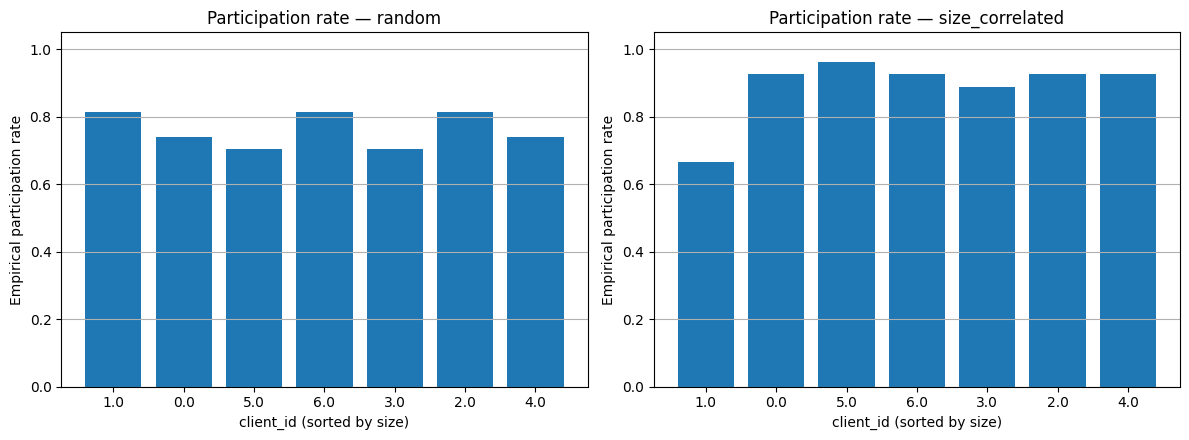

In [10]:
if not part_df.empty:
    dropout_regimes = [r for r in part_df["regime"].unique() if r != "full"]
    if dropout_regimes:
        fig, axes = plt.subplots(1, len(dropout_regimes), figsize=(6 * len(dropout_regimes), 4.5), squeeze=False)
        for ax, regime in zip(axes[0], dropout_regimes):
            sub = part_df[part_df["regime"] == regime]
            # one bar per client, averaged across strategies (draws use the same
            # seed, so q=0 / q=2 / q=5 should look basically identical here)
            by_client = sub.groupby("client_id").agg(
                mean_size=("mean_size", "mean"),
                participation_rate=("participation_rate", "mean"),
            ).sort_values("mean_size")
            ax.bar(by_client.index.astype(str), by_client["participation_rate"])
            ax.set_title(f"Participation rate — {regime}")
            ax.set_xlabel("client_id (sorted by size)")
            ax.set_ylabel("Empirical participation rate")
            ax.set_ylim(0, 1.05)
            ax.grid(True, axis="y")
        fig.tight_layout()
        plt.show()
    else:
        print("Only full-participation runs found -- nothing to plot here.")